In [2]:
import pandas as pd


In [3]:

df = pd.read_csv("Hitters.csv")

In [4]:
df.dropna(inplace=True)

In [5]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

df = pd.get_dummies(df, drop_first=True)
X = df.drop("Salary", axis=1)
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline = make_pipeline(StandardScaler(), LassoCV(cv=5))

In [6]:
X_train.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
226,547,137,2,58,47,12,2,1038,271,3,129,80,24,261,459,22,False,True,False
220,299,75,6,38,23,26,3,580,160,8,71,33,44,212,1,2,True,False,True
128,584,158,15,70,84,42,5,2358,636,58,265,316,134,331,20,4,True,False,True
222,381,110,9,61,45,32,7,3015,834,40,451,249,168,228,7,5,True,False,True
81,255,70,7,49,35,43,15,6311,1661,154,1019,608,820,51,54,8,True,False,True


In [7]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('lassocv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True


In [8]:
print(pipeline.get_params()['lassocv'].coef_)
df.columns

[  0.         109.64851299   0.           0.           0.
  33.15524309   0.           0.           0.           0.
  61.2230704  143.99018136   0.          59.73092901  -0.
  -0.           0.         -41.66220619   0.        ]


Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
       'Errors', 'Salary', 'League_N', 'Division_W', 'NewLeague_N'],
      dtype='str')

In [9]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

X, y = df.drop("Salary", axis=1), df['Salary']
poly_feat = PolynomialFeatures(degree=2, include_bias=False)
poly_X = poly_feat.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(poly_X, y, test_size=0.3)

pipeline = make_pipeline(StandardScaler(), ElasticNetCV(cv=5))

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


In [10]:
pipeline.get_params()

{'memory': None,
 'steps': [('standardscaler', StandardScaler()),
  ('elasticnetcv', ElasticNetCV(cv=5))],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'elasticnetcv': ElasticNetCV(cv=5),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'elasticnetcv__alphas': 'warn',
 'elasticnetcv__copy_X': True,
 'elasticnetcv__cv': 5,
 'elasticnetcv__eps': 0.001,
 'elasticnetcv__fit_intercept': True,
 'elasticnetcv__l1_ratio': 0.5,
 'elasticnetcv__max_iter': 1000,
 'elasticnetcv__n_alphas': 'deprecated',
 'elasticnetcv__n_jobs': None,
 'elasticnetcv__positive': False,
 'elasticnetcv__precompute': 'auto',
 'elasticnetcv__random_state': None,
 'elasticnetcv__selection': 'cyclic',
 'elasticnetcv__tol': 0.0001,
 'elasticnetcv__verbose': 0}

In [11]:
root_mean_squared_error(y_test, y_pred)


398.26897570751805

In [12]:
df['Salary'].describe()

count     263.000000
mean      535.925882
std       451.118681
min        67.500000
25%       190.000000
50%       425.000000
75%       750.000000
max      2460.000000
Name: Salary, dtype: float64

<Axes: >

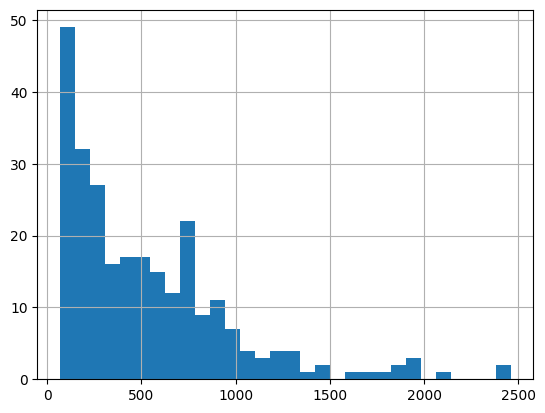

In [15]:
import matplotlib.pyplot as plt
df['Salary'].hist(bins=30)